In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [7]:
def create_outline(state: BlogState) -> BlogState:
    title = state["title"]
    prompt = f"Generate a detailed outline for a blog on the topic: {title}"
    outline = model.invoke(prompt).content
    state["outline"] = outline
    return state

In [8]:
def create_blog(state: BlogState) -> BlogState:
    title = state["title"]
    outline = state["outline"]
    prompt = f"Write a detailed blog on the topic: {title} using the following outline:\n{outline}"
    content = model.invoke(prompt).content
    state["content"] = content
    return state

In [9]:
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

workflow = graph.compile()

In [10]:
initial_state = {"title": "The Future of AI"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'The Future of AI', 'outline': "**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its current impact on society\n* Importance of exploring the future of AI\n* Thesis statement: As AI technology continues to advance, it is essential to examine the potential developments, benefits, and challenges that will shape its future.\n\n**II. Current State of AI**\n\n* Overview of current AI applications (e.g., virtual assistants, image recognition, natural language processing)\n* Discussion of AI's current limitations (e.g., lack of common sense, limited domain knowledge)\n* Examples of AI's current successes (e.g., medical diagnosis, autonomous vehicles)\n\n**III. Future Developments in AI**\n\n* **Advancements in Machine Learning**\n\t+ Explanation of deep learning and its potential applications\n\t+ Discussion of emerging trends in machine learning (e.g., transfer learning, reinforcement learning)\n* **Rise of Explainable AI (XAI)**\n\t+ Importance of unders

In [11]:
print(final_state['outline'])

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its current impact on society
* Importance of exploring the future of AI
* Thesis statement: As AI technology continues to advance, it is essential to examine the potential developments, benefits, and challenges that will shape its future.

**II. Current State of AI**

* Overview of current AI applications (e.g., virtual assistants, image recognition, natural language processing)
* Discussion of AI's current limitations (e.g., lack of common sense, limited domain knowledge)
* Examples of AI's current successes (e.g., medical diagnosis, autonomous vehicles)

**III. Future Developments in AI**

* **Advancements in Machine Learning**
	+ Explanation of deep learning and its potential applications
	+ Discussion of emerging trends in machine learning (e.g., transfer learning, reinforcement learning)
* **Rise of Explainable AI (XAI)**
	+ Importance of understanding AI decision-making processes
	+ Overview of XAI techniq

In [12]:
print(final_state['content'])

**The Future of AI: Exploring the Potential Developments, Benefits, and Challenges**

**Introduction**

Artificial Intelligence (AI) has become an integral part of our daily lives, transforming the way we interact, work, and live. From virtual assistants like Siri and Alexa to image recognition and natural language processing, AI has made significant strides in recent years. However, as AI technology continues to advance, it is essential to examine the potential developments, benefits, and challenges that will shape its future. In this blog, we will delve into the current state of AI, explore future developments, and discuss the potential benefits and challenges that lie ahead. As AI technology continues to advance, it is essential to examine the potential developments, benefits, and challenges that will shape its future.

**Current State of AI**

AI has made tremendous progress in recent years, with applications in various industries such as healthcare, finance, and transportation. Cu

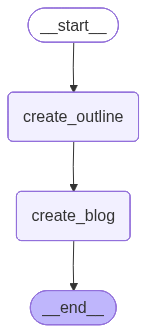

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())